# Goodreads EDA — History & Biography

Exploratory analysis for the Goodreads History & Biography category, designed as evidence for a future hybrid recommender. The notebook separates general data-quality diagnostics from History-specific hypotheses, so each downstream feature decision is tied to observed behavior rather than copied from another category.

This EDA is diagnostic only: it does not write curated files and does not execute the processing pipeline.

In [1]:
from pathlib import Path
import os, sys
from itertools import combinations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import BOOK_NUMERIC_COLUMNS, CATEGORIES
from src.utils.io import read_jsonl_sample
from src.utils.cleaning import clean_interactions, _shelves_summary
from src.utils.eda import (
    build_eda_profile,
    author_profile,
    shelves_profile,
    series_profile,
    engagement_profile,
    reading_duration_profile,
    user_rating_behavior,
    platform_growth_profile,
)

sns.set_theme(style='whitegrid')
BROWN = 'saddlebrown'
ORANGE = 'darkorange'

## 1. Inputs and Loading

The EDA uses controlled samples from the raw Goodreads files. The sample size is large enough to inspect missingness, long tails, interaction sparsity, and History-specific shelf taxonomy without materializing the full category in memory.

In [2]:
CATEGORY = 'history_biography'
cfg = CATEGORIES[CATEGORY]
BOOKS_SAMPLE = 50_000
INTERACTIONS_SAMPLE = 250_000

print(cfg.books_file)
print(cfg.interactions_file)

/home/nakato/projects/BigBook/data/raw/goodreads_books_history_biography.json.gz
/home/nakato/projects/BigBook/data/raw/goodreads_interactions_history_biography.json.gz


In [3]:
books_raw = read_jsonl_sample(cfg.books_file, nrows=BOOKS_SAMPLE)
interactions_raw = read_jsonl_sample(cfg.interactions_file, nrows=INTERACTIONS_SAMPLE)

print(f'books_raw:         {books_raw.shape}')
print(f'interactions_raw:  {interactions_raw.shape}')

books_raw:         (50000, 29)
interactions_raw:  (250000, 10)


## 2. Hypothesis Matrix

Each History-specific section below tests one hypothesis and converts it into a recommendation decision. The final model target is hybrid: collaborative signals from users and ratings, plus content signals from author, shelves, edition metadata, and temporality.

In [4]:
hypothesis_matrix = pd.DataFrame([
    {
        'id': 'H1',
        'hypothesis': 'Author authority matters more than serialization.',
        'evidence_needed': 'Author role distribution, primary-author concentration, and non-primary roles.',
        'analysis': 'Author list parsing and role audit.',
        'expected_recommender_decision': 'Use role-filtered primary_author_id; avoid translator/editor contamination.',
    },
    {
        'id': 'H2',
        'hypothesis': 'Popular shelves encode real History subgenres.',
        'evidence_needed': 'Theme presence, theme co-occurrence, and theme-level rating/popularity differences.',
        'analysis': 'Local History shelf taxonomy.',
        'expected_recommender_decision': 'Create thematic shelf features for content and hybrid retrieval.',
    },
    {
        'id': 'H3',
        'hypothesis': 'Popularity is not the same as quality.',
        'evidence_needed': 'Correlations between average_rating and to_read_count / ratings_count / reviews.',
        'analysis': 'Correlation table and scatter plots.',
        'expected_recommender_decision': 'Model demand and satisfaction as separate feature families.',
    },
    {
        'id': 'H4',
        'hypothesis': 'History has collection behavior: many users save without rating or reading.',
        'evidence_needed': 'shelf_only, rating_only, review, and read_no_rating interaction mix.',
        'analysis': 'Interaction mode profile and reading-duration availability.',
        'expected_recommender_decision': 'Separate intent, actual reading, and explicit rating signals.',
    },
    {
        'id': 'H5',
        'hypothesis': 'Series is a secondary signal in this category.',
        'evidence_needed': 'Standalone vs in-series share and differences in rating/popularity.',
        'analysis': 'Series profile and comparison plots.',
        'expected_recommender_decision': 'Keep series_count as a weak edition/collection feature, not a main route.',
    },
    {
        'id': 'H6',
        'hypothesis': 'Publication temporality needs validation and segmentation.',
        'evidence_needed': 'Impossible years, valid-year distribution, and interaction date completeness.',
        'analysis': 'Publication-year and Goodreads-date diagnostics.',
        'expected_recommender_decision': 'Use cleaned year bins only after invalid years are isolated.',
    },
    {
        'id': 'H7',
        'hypothesis': 'Format, language, and publisher represent edition/translation context.',
        'evidence_needed': 'Missingness, cardinality, and category distributions.',
        'analysis': 'Categorical profiles and format validation.',
        'expected_recommender_decision': 'Use selectively; avoid zero-variance or high-missing fields as primary signals.',
    },
    {
        'id': 'H8',
        'hypothesis': 'User rating bias matters for a hybrid recommender.',
        'evidence_needed': 'Mean rating per user and strict/balanced/generous user shares.',
        'analysis': 'User rating behavior on explicit ratings.',
        'expected_recommender_decision': 'Normalize or include user bias in collaborative scoring.',
    },
])
display(hypothesis_matrix)

,id,hypothesis,evidence_needed,analysis,expected_recommender_decision
0,H1,Author authority matters more than serialization.,"Author role distribution, primary-author conce...",Author list parsing and role audit.,Use role-filtered primary_author_id; avoid tra...
1,H2,Popular shelves encode real History subgenres.,"Theme presence, theme co-occurrence, and theme...",Local History shelf taxonomy.,Create thematic shelf features for content and...
2,H3,Popularity is not the same as quality.,Correlations between average_rating and to_rea...,Correlation table and scatter plots.,Model demand and satisfaction as separate feat...
3,H4,History has collection behavior: many users sa...,"shelf_only, rating_only, review, and read_no_r...",Interaction mode profile and reading-duration ...,"Separate intent, actual reading, and explicit ..."
4,H5,Series is a secondary signal in this category.,Standalone vs in-series share and differences ...,Series profile and comparison plots.,Keep series_count as a weak edition/collection...
5,H6,Publication temporality needs validation and s...,"Impossible years, valid-year distribution, and...",Publication-year and Goodreads-date diagnostics.,Use cleaned year bins only after invalid years...
6,H7,"Format, language, and publisher represent edit...","Missingness, cardinality, and category distrib...",Categorical profiles and format validation.,Use selectively; avoid zero-variance or high-m...
7,H8,User rating bias matters for a hybrid recommen...,Mean rating per user and strict/balanced/gener...,User rating behavior on explicit ratings.,Normalize or include user bias in collaborativ...


## 3. General Data-Quality Diagnostics

**Hypothesis:** Before any History-specific modeling, raw Goodreads records must be profiled for schema drift, empty strings, string-encoded numerics, duplicate keys, missing dates, and `rating = 0` conventions.

**Evidence:** schema summaries, explicit null-vs-empty-string tables, duplicate counts, raw rating distribution, and date completeness.

In [5]:
def missing_with_empty_strings(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'nulls_raw': df.isna().sum(),
        'empty_strings_raw': df.astype('string').eq('').sum(),
        'non_null_raw': df.notna().sum(),
    })
    out['missing_like_total'] = out['nulls_raw'] + out['empty_strings_raw']
    out['missing_like_pct'] = out['missing_like_total'] / len(df) if len(df) else 0
    return out.sort_values(['missing_like_pct', 'empty_strings_raw'], ascending=False).reset_index(names='column')

artifacts, summary = build_eda_profile(
    books_raw=books_raw,
    interactions_raw=interactions_raw,
    book_numeric_columns=BOOK_NUMERIC_COLUMNS,
    interaction_numeric_columns=['rating'],
)

books_missing_explicit = missing_with_empty_strings(books_raw)
interactions_missing_explicit = missing_with_empty_strings(interactions_raw)

print('=== Summary ===')
display(summary)
print('\\n=== Books schema ===')
display(artifacts['books_schema'])
print('\\n=== Interactions schema ===')
display(artifacts['interactions_schema'])
print('\\n=== Books: nulls vs empty strings ===')
display(books_missing_explicit.head(20))
print('\\n=== Interactions: nulls vs empty strings ===')
display(interactions_missing_explicit.head(20))

=== Summary ===


,metric,value
0,books_raw_rows,50000.000000
1,interactions_raw_rows,250000.000000
2,books_clean_rows,50000.000000
3,interactions_clean_rows,250000.000000
4,books_columns,29.000000
5,interactions_columns,10.000000
6,explicit_rating_pct,0.412256


\n=== Books schema ===


,column,dtype,non_null,nulls,unique
0,asin,str,50000,0,6774
1,authors,object,50000,0,32994
2,average_rating,str,50000,0,272
3,book_id,str,50000,0,50000
4,country_code,str,50000,0,1
5,description,str,50000,0,41331
6,edition_information,str,50000,0,1721
7,format,str,50000,0,114
8,image_url,str,50000,0,28211
9,is_ebook,str,50000,0,2


\n=== Interactions schema ===


,column,dtype,non_null,nulls,unique
0,book_id,str,250000,0,66219
1,date_added,str,250000,0,247641
2,date_updated,str,250000,0,246881
3,is_read,bool,250000,0,2
4,rating,int64,250000,0,6
5,read_at,str,250000,0,32908
6,review_id,str,250000,0,250000
7,review_text_incomplete,str,250000,0,18867
8,started_at,str,250000,0,22974
9,user_id,str,250000,0,3517


\n=== Books: nulls vs empty strings ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,edition_information,str,0,45980,50000,45980,0.9196
1,asin,str,0,43227,50000,43227,0.86454
2,kindle_asin,str,0,25763,50000,25763,0.51526
3,language_code,str,0,25610,50000,25610,0.5122
4,publication_day,str,0,18640,50000,18640,0.3728
5,publication_month,str,0,16387,50000,16387,0.32774
6,isbn,str,0,13945,50000,13945,0.2789
7,num_pages,str,0,13642,50000,13642,0.27284
8,format,str,0,11681,50000,11681,0.23362
9,publisher,str,0,11240,50000,11240,0.2248


\n=== Interactions: nulls vs empty strings ===


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
0,review_text_incomplete,str,0,230853,250000,230853,0.923412
1,started_at,str,0,210340,250000,210340,0.84136
2,read_at,str,0,198903,250000,198903,0.795612
3,user_id,str,0,0,250000,0,0.0
4,book_id,str,0,0,250000,0,0.0
5,review_id,str,0,0,250000,0,0.0
6,is_read,bool,0,0,250000,0,0.0
7,rating,int64,0,0,250000,0,0.0
8,date_added,str,0,0,250000,0,0.0
9,date_updated,str,0,0,250000,0,0.0


In [6]:
rating_distribution = interactions_raw['rating'].value_counts(dropna=False).sort_index().rename_axis('rating').reset_index(name='interactions')
rating_distribution['pct'] = rating_distribution['interactions'] / len(interactions_raw)
zero_rating_pct = float((interactions_raw['rating'] == 0).mean())

print('=== Raw interaction rating distribution ===')
display(rating_distribution)
print(f'rating = 0 share: {zero_rating_pct:.1%}')

print('\\n=== Duplicate diagnostics ===')
display(artifacts['duplicates'])

for col in ['date_added', 'date_updated', 'read_at', 'started_at']:
    if col in interactions_raw.columns:
        empty = interactions_raw[col].astype('string').eq('').sum()
        print(f'{col:12s} empty strings: {empty:>8,} ({empty / len(interactions_raw):.1%})')

=== Raw interaction rating distribution ===


,rating,interactions,pct
0,0,146936,0.587744
1,1,1688,0.006752
2,2,6127,0.024508
3,3,24307,0.097228
4,4,39733,0.158932
5,5,31209,0.124836


rating = 0 share: 58.8%
\n=== Duplicate diagnostics ===


,key,duplicates,records
0,books.book_id,0,50000
1,books.work_id,10069,50000
2,interactions.review_id,0,250000
3,interactions.user_id_book_id,0,250000


date_added   empty strings:        0 (0.0%)
date_updated empty strings:        0 (0.0%)
read_at      empty strings:  198,903 (79.6%)
started_at   empty strings:  210,340 (84.1%)


**Decision for recommender:** Treat empty strings as missing before type conversion, parse numeric metadata with coercion, treat `rating = 0` as missing feedback rather than a negative rating, and preserve duplicate diagnostics before any future curation. Date-derived features should be optional because `started_at` and `read_at` are frequently empty.

## 4. H1 — Author Authority and Role Contamination

**Hypothesis:** In History & Biography, author authority is more important than serialization. Author roles must be audited because editors, translators, contributors, and compilers can contaminate `primary_author_id` if every author entry is treated equally.

**Evidence:** author counts per book, primary role distribution, and concentration of top primary authors.

,author_count_bin,books,pct
0,1,38592,0.77184
1,2,9006,0.18012
2,3,1789,0.03578
3,4,362,0.00724
4,5,104,0.00208
5,6,34,0.00068
6,7,36,0.00072
7,8,12,0.00024
8,9,17,0.00034
9,10,7,0.00014


,role,books,pct
0,<blank>,49002,0.98004
1,Editor,631,0.01262
2,Contributor,35,0.00070
3,editor,27,0.00054
4,Translation,20,0.00040
5,Reading,18,0.00036
6,Author,17,0.00034
7,Introduction,13,0.00026
8,Compilation,11,0.00022
9,Translator,11,0.00022


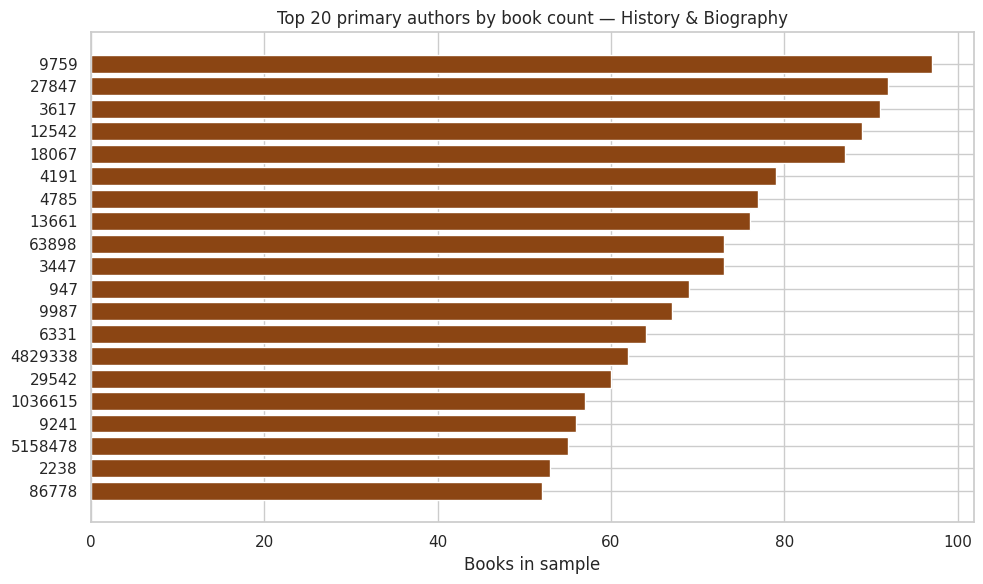

Primary blank role share: 98.0%
Unique primary authors in top-authors table: 27,074


In [7]:
author_artifacts = author_profile(books_raw)

display(author_artifacts['author_count_dist'])
display(author_artifacts['role_dist'].head(20))

top_authors = author_artifacts['top_authors'].head(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_authors['author_id'].astype(str)[::-1], top_authors['book_count'][::-1], color=BROWN)
ax.set_xlabel('Books in sample')
ax.set_title('Top 20 primary authors by book count — History & Biography')
plt.tight_layout()
plt.show()

blank_role_pct = float(author_artifacts['role_dist'].loc[author_artifacts['role_dist']['role'].eq('<blank>'), 'pct'].iloc[0])
print(f'Primary blank role share: {blank_role_pct:.1%}')
print(f"Unique primary authors in top-authors table: {author_artifacts['top_authors']['author_id'].nunique():,}")

**Decision for recommender:** Build author features from role-filtered primary authors. Keep non-primary roles as optional metadata, but do not allow translators, editors, foreword writers, or contributors to define the main authorship embedding or collaborative author similarity.

## 5. H2 — History Shelf Taxonomy

**Hypothesis:** `popular_shelves` contains History-specific subgenre signals that are more useful than a single category label. Shelves must be mapped into thematic groups before being used in a hybrid recommender.

**Evidence:** top shelves, theme presence, theme co-occurrence, and theme-level differences in rating, demand, and review volume.

In [8]:
HISTORY_SHELF_GROUPS = {
    'biography_memoir': ['biography', 'memoir', 'autobiography', 'bio', 'biographies', 'memoirs'],
    'military_war': ['war', 'military', 'wwii', 'world-war', 'civil-war', 'battle', 'soldier'],
    'politics_power': ['politics', 'political', 'president', 'government', 'revolution', 'leadership'],
    'ancient_medieval': ['ancient', 'medieval', 'middle-ages', 'rome', 'roman', 'greece', 'egypt'],
    'regional_world': ['world-history', 'american-history', 'us-history', 'european-history', 'british-history', 'asia', 'africa'],
    'historical_fiction': ['historical-fiction', 'historical-romance', 'hist-fic'],
    'science_ideas': ['science', 'history-of-science', 'philosophy', 'religion', 'ideas', 'intellectual-history'],
    'general_nonfiction': ['history', 'non-fiction', 'nonfiction', 'historical'],
}


def shelf_names(value):
    if not isinstance(value, list):
        return []
    return [str(item.get('name', '')).lower() for item in value if isinstance(item, dict) and item.get('name')]


def has_theme(names, keywords):
    return any(any(keyword in name for keyword in keywords) for name in names)


def history_theme_profile(books: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    data = books[['book_id', 'popular_shelves', 'average_rating', 'ratings_count', 'text_reviews_count']].copy()
    data['shelf_names'] = data['popular_shelves'].map(shelf_names)
    shelf_flat = data['popular_shelves'].map(lambda s: _shelves_summary(s, top_n=30)).apply(pd.Series)
    data['to_read_count'] = pd.to_numeric(shelf_flat['to_read_count'], errors='coerce')
    for col in ['average_rating', 'ratings_count', 'text_reviews_count']:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    for theme, keywords in HISTORY_SHELF_GROUPS.items():
        data[theme] = data['shelf_names'].map(lambda names, kws=keywords: has_theme(names, kws))

    rows = []
    for theme in HISTORY_SHELF_GROUPS:
        subset = data[data[theme]]
        rows.append({
            'theme': theme,
            'books': len(subset),
            'pct_books': len(subset) / len(data) if len(data) else 0,
            'avg_rating_mean': subset['average_rating'].mean(),
            'ratings_count_median': subset['ratings_count'].median(),
            'text_reviews_count_median': subset['text_reviews_count'].median(),
            'to_read_median': subset['to_read_count'].median(),
        })
    theme_summary = pd.DataFrame(rows).sort_values('books', ascending=False)

    pair_rows = []
    theme_columns = list(HISTORY_SHELF_GROUPS)
    for a, b in combinations(theme_columns, 2):
        count = int((data[a] & data[b]).sum())
        if count:
            pair_rows.append({'theme_a': a, 'theme_b': b, 'books': count, 'pct_books': count / len(data)})
    cooccurrence = pd.DataFrame(pair_rows).sort_values('books', ascending=False)
    return data, theme_summary, cooccurrence

shelf_artifacts = shelves_profile(books_raw, top_n=40)
theme_books, theme_summary, theme_cooccurrence = history_theme_profile(books_raw)

print('=== Top raw shelves ===')
display(shelf_artifacts['top_shelf_names'].head(30))
print('\\n=== History thematic shelf groups ===')
display(theme_summary)
print('\\n=== Theme co-occurrence ===')
display(theme_cooccurrence.head(20))

=== Top raw shelves ===


,shelf_name,book_count
0,to-read,49729
1,currently-reading,43161
2,history,33094
3,owned,30541
4,historical,27453
5,favorites,27393
6,books-i-own,26002
7,non-fiction,25739
8,default,23192
9,fiction,22619


\n=== History thematic shelf groups ===


,theme,books,pct_books,avg_rating_mean,ratings_count_median,text_reviews_count_median,to_read_median
7,general_nonfiction,49714,0.99428,3.877192,31.0,5.0,230.0
5,historical_fiction,24036,0.48072,3.873133,38.0,6.0,444.0
0,biography_memoir,22198,0.44396,3.894338,36.0,6.0,254.0
3,ancient_medieval,20320,0.40640,3.865988,35.0,6.0,364.0
1,military_war,16953,0.33906,3.915424,35.0,6.0,356.0
4,regional_world,15237,0.30474,3.907910,36.0,6.0,385.0
6,science_ideas,14468,0.28936,3.913753,36.0,6.0,332.0
2,politics_power,11834,0.23668,3.914005,36.0,6.0,332.0


\n=== Theme co-occurrence ===


,theme_a,theme_b,books,pct_books
26,historical_fiction,general_nonfiction,24036,0.48072
6,biography_memoir,general_nonfiction,21912,0.43824
21,ancient_medieval,general_nonfiction,20302,0.40604
12,military_war,general_nonfiction,16935,0.33870
19,ancient_medieval,historical_fiction,16271,0.32542
24,regional_world,general_nonfiction,15229,0.30458
27,science_ideas,general_nonfiction,14443,0.28886
17,politics_power,general_nonfiction,11820,0.23640
10,military_war,historical_fiction,9557,0.19114
3,biography_memoir,regional_world,8912,0.17824


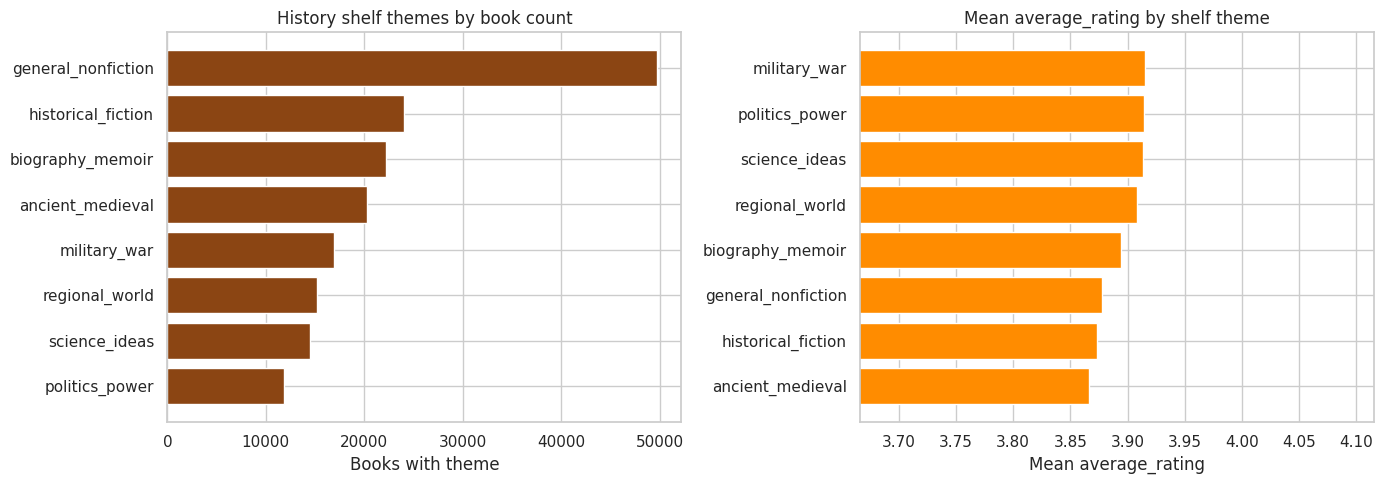

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_theme = theme_summary.sort_values('books')
axes[0].barh(plot_theme['theme'], plot_theme['books'], color=BROWN)
axes[0].set_title('History shelf themes by book count')
axes[0].set_xlabel('Books with theme')

plot_rating = theme_summary.sort_values('avg_rating_mean')
axes[1].barh(plot_rating['theme'], plot_rating['avg_rating_mean'], color=ORANGE)
axes[1].set_title('Mean average_rating by shelf theme')
axes[1].set_xlabel('Mean average_rating')
axes[1].set_xlim(max(0, plot_rating['avg_rating_mean'].min() - 0.2), min(5, plot_rating['avg_rating_mean'].max() + 0.2))
plt.tight_layout()
plt.show()

**Decision for recommender:** Use thematic shelf groups as content features and candidate filters. Keep raw shelves for later experimentation, but expose grouped themes first because they separate biographies, military history, political history, regional history, historical fiction, and idea/science history more cleanly than the broad category label.

## 6. H3 — Popularity, Demand, and Quality Are Different Signals

**Hypothesis:** The most saved or most rated History books are not necessarily the highest-rated books. Demand (`to_read_count`), visibility (`ratings_count`, `text_reviews_count`), and satisfaction (`average_rating`) should remain separate.

**Evidence:** correlations and scatter plots between satisfaction and demand/visibility metrics.

,feature,target,pearson_r
0,to_read_count,average_rating,0.088331
1,ratings_count,average_rating,0.013245
2,text_reviews_count,average_rating,0.016118


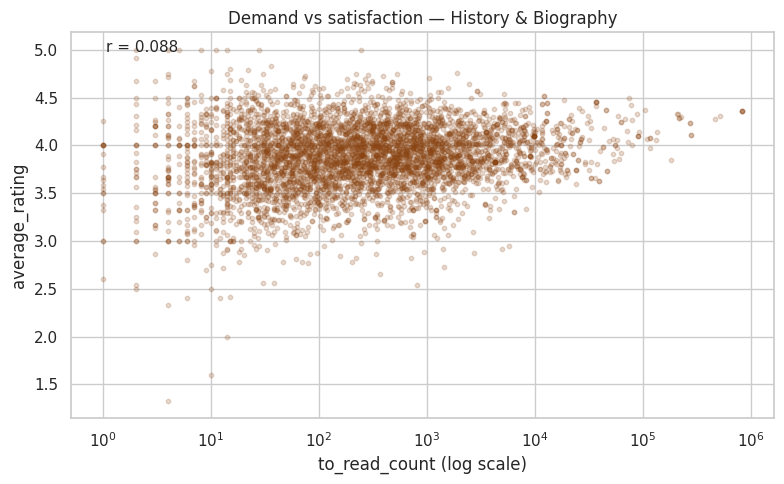

In [10]:
pop_quality = theme_books[['average_rating', 'ratings_count', 'text_reviews_count', 'to_read_count']].copy()
correlation_pairs = []
for feature in ['to_read_count', 'ratings_count', 'text_reviews_count']:
    corr = pop_quality[[feature, 'average_rating']].dropna().corr().iloc[0, 1]
    correlation_pairs.append({'feature': feature, 'target': 'average_rating', 'pearson_r': corr})
quality_corr = pd.DataFrame(correlation_pairs)
display(quality_corr)

sample = pop_quality.dropna(subset=['to_read_count', 'average_rating']).sample(
    min(5_000, pop_quality.dropna(subset=['to_read_count', 'average_rating']).shape[0]),
    random_state=42,
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(sample['to_read_count'], sample['average_rating'], alpha=0.2, s=10, color=BROWN)
ax.set_xscale('log')
ax.set_xlabel('to_read_count (log scale)')
ax.set_ylabel('average_rating')
ax.set_title('Demand vs satisfaction — History & Biography')
r = quality_corr.loc[quality_corr['feature'].eq('to_read_count'), 'pearson_r'].iloc[0]
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11)
plt.tight_layout()
plt.show()

**Decision for recommender:** Do not use popularity as a proxy for quality. Keep `to_read_count`, `ratings_count`, and `text_reviews_count` as demand/visibility features, while explicit ratings and adjusted user feedback should drive satisfaction estimates.

## 7. H4 and H8 — Interaction Modes, Reading Completion, and User Bias

**Hypothesis:** History users often collect books into shelves before reading, and explicit ratings are shaped by user-level generosity. A hybrid recommender needs separate signals for intent, reading evidence, explicit rating, and user bias.

**Evidence:** engagement modes, duration availability, reading-duration distribution, and strict/balanced/generous user profiles.

In [11]:
interactions_temp = clean_interactions(interactions_raw)
eng_artifacts = engagement_profile(books_raw, interactions_temp)
duration_artifacts = reading_duration_profile(interactions_temp)
user_artifacts = user_rating_behavior(interactions_temp)
growth = platform_growth_profile(interactions_temp)

print('=== Engagement modes ===')
display(eng_artifacts['engagement_modes'])
print('\\n=== Reading duration stats ===')
print(f"Interactions with valid duration: {duration_artifacts['pct_with_duration']:.1%}")
display(duration_artifacts['duration_stats'])
print('\\n=== Ratings per user ===')
display(user_artifacts['ratings_per_user'])
print('\\n=== User rating-bias groups ===')
display(user_artifacts['user_type_dist'])

=== Engagement modes ===


,mode,interactions,pct
0,shelf_only,138615,0.554460
1,rating_only,84671,0.338684
2,review,19119,0.076476
3,read_no_rating,7595,0.030380


\n=== Reading duration stats ===
Interactions with valid duration: 13.5%


,stat,value
0,count,33718.000000
1,mean,18.774482
2,std,40.759463
3,min,0.000000
4,25%,2.000000
5,50%,6.000000
6,75%,16.000000
7,90%,43.000000
8,95%,82.000000
9,99%,237.000000


\n=== Ratings per user ===


,stat,value
0,count,3370.000000
1,mean,30.582789
2,std,50.892554
3,min,1.000000
4,25%,6.000000
5,50%,15.000000
6,75%,34.000000
7,90%,70.000000
8,95%,108.000000
9,99%,255.930000


\n=== User rating-bias groups ===


,user_type,users,pct
0,generous,2303,0.752369
1,balanced,697,0.227703
2,strict,61,0.019928


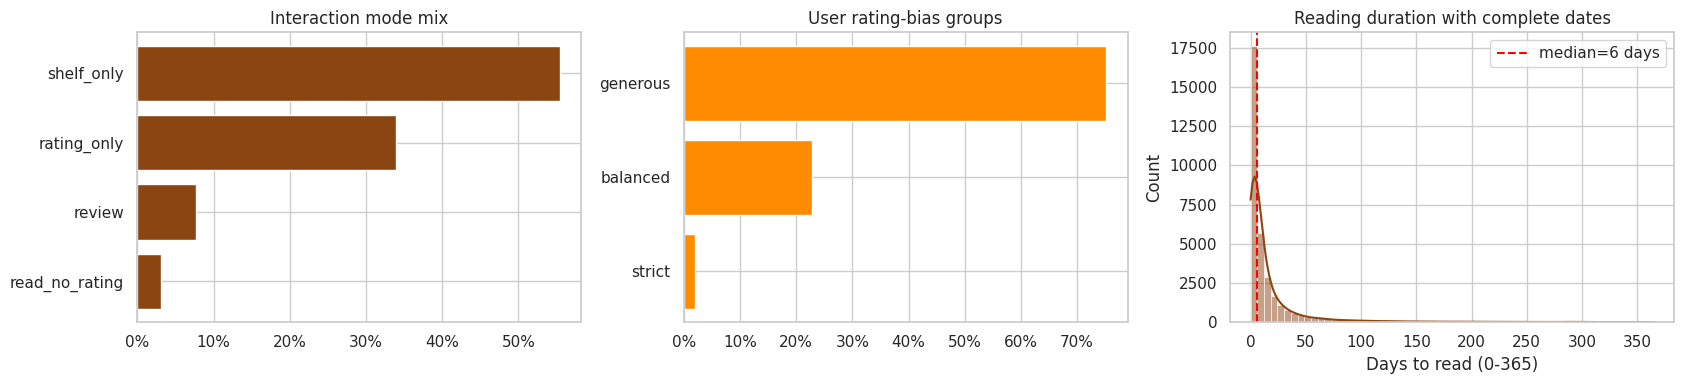

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

modes = eng_artifacts['engagement_modes'].copy()
axes[0].barh(modes['mode'][::-1], modes['pct'][::-1], color=BROWN)
axes[0].set_title('Interaction mode mix')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

user_types = user_artifacts['user_type_dist'].copy()
axes[1].barh(user_types['user_type'][::-1], user_types['pct'][::-1], color=ORANGE)
axes[1].set_title('User rating-bias groups')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

dur = duration_artifacts['duration_distribution']
if len(dur) > 0:
    sns.histplot(dur, bins=60, ax=axes[2], kde=True, color=BROWN)
    axes[2].axvline(dur.median(), color='red', linestyle='--', label=f'median={dur.median():.0f} days')
    axes[2].legend()
axes[2].set_title('Reading duration with complete dates')
axes[2].set_xlabel('Days to read (0-365)')

plt.tight_layout()
plt.show()

,year,new_interactions,pct_with_rating
0,2005,8,1.000000
1,2006,21,0.666667
2,2007,965,0.866321
3,2008,12075,0.682402
4,2009,5802,0.517752
5,2010,4629,0.530352
6,2011,5075,0.499113
7,2012,54017,0.595498
8,2013,37445,0.393457
9,2014,32674,0.370845


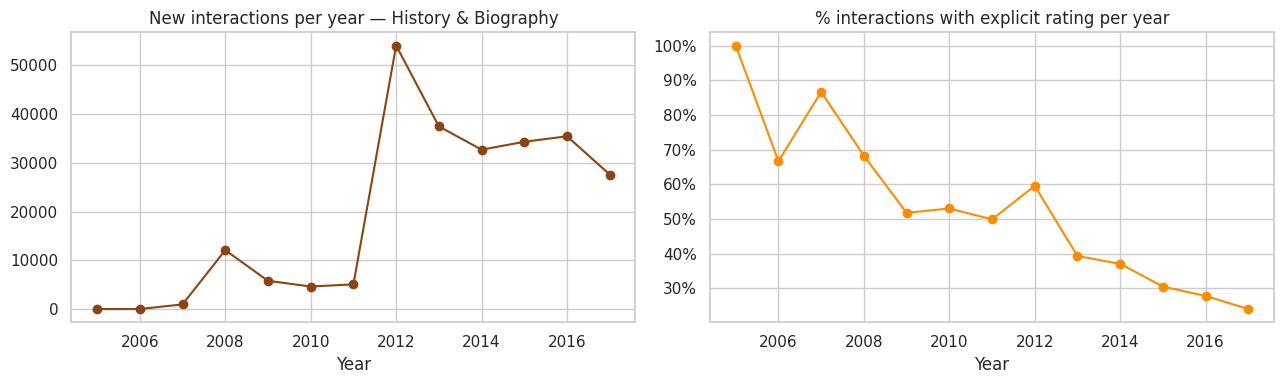

In [13]:
if not growth.empty:
    display(growth)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    growth.set_index('year')['new_interactions'].plot(ax=axes[0], marker='o', color=BROWN)
    axes[0].set_title('New interactions per year — History & Biography')
    axes[0].set_xlabel('Year')
    growth.set_index('year')['pct_with_rating'].plot(ax=axes[1], marker='o', color=ORANGE)
    axes[1].set_title('% interactions with explicit rating per year')
    axes[1].set_xlabel('Year')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.show()

**Decision for recommender:** Treat `shelf_only` as intent, explicit ratings as satisfaction, reviews as high-confidence engagement, and complete reading dates as sparse behavioral evidence. Add user-bias normalization or a user-rating-bias feature before collaborative scoring.

## 8. H5 — Series Is Secondary in History & Biography

**Hypothesis:** Series membership is not the dominant structure for this category. It may describe collections, editions, or multi-volume histories, but should not drive recommendation routes.

**Evidence:** standalone-vs-series share and rating/popularity differences between both groups.

In [14]:
series_artifacts = series_profile(books_raw)
display(series_artifacts['standalone_vs_series'])
display(series_artifacts['series_length_dist'].head(20))

series_books = books_raw.copy()
series_books['series_count_num'] = series_books['series'].map(lambda x: len(x) if isinstance(x, list) else 0)
series_books['in_series'] = series_books['series_count_num'].gt(0)
for col in ['average_rating', 'ratings_count']:
    series_books[col] = pd.to_numeric(series_books[col], errors='coerce')

series_comparison = series_books.groupby('in_series').agg(
    books=('book_id', 'count'),
    avg_rating_mean=('average_rating', 'mean'),
    avg_rating_median=('average_rating', 'median'),
    ratings_count_median=('ratings_count', 'median'),
    ratings_count_p95=('ratings_count', lambda s: s.quantile(0.95)),
).reset_index()
display(series_comparison)

,group,books,pct
0,standalone,37883,0.75766
1,in_series,12117,0.24234


,series_count,books,pct
0,0,37883,0.75766
1,1,11364,0.22728
2,2,684,0.01368
3,3,60,0.00120
4,4,9,0.00018


,in_series,books,avg_rating_mean,avg_rating_median,ratings_count_median,ratings_count_p95
0,False,37883,3.859476,3.88,29.0,766.0
1,True,12117,3.931826,3.94,40.0,1322.6


/tmp/ipykernel_3632930/1317888350.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Standalone', 'In series'])


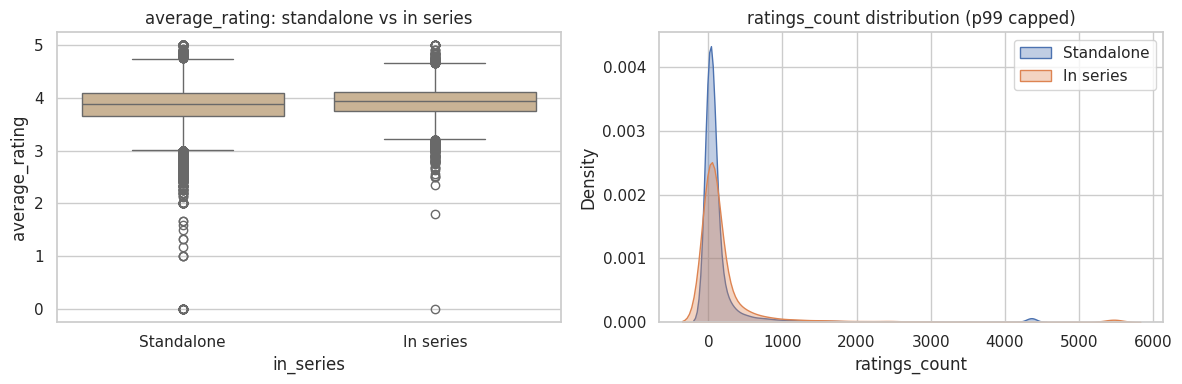

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=series_books.dropna(subset=['average_rating']), x='in_series', y='average_rating', ax=axes[0], color='tan')
axes[0].set_title('average_rating: standalone vs in series')
axes[0].set_xticklabels(['Standalone', 'In series'])

for label, grp in series_books.groupby('in_series'):
    rc = grp['ratings_count'].dropna()
    if len(rc) > 1:
        sns.kdeplot(rc.clip(upper=rc.quantile(0.99)), ax=axes[1], label='In series' if label else 'Standalone', fill=True, alpha=0.35)
axes[1].set_title('ratings_count distribution (p99 capped)')
axes[1].set_xlabel('ratings_count')
axes[1].legend()
plt.tight_layout()
plt.show()

**Decision for recommender:** Keep `series_count` and `in_series` as secondary metadata. They can help distinguish multi-volume works and collections, but thematic shelves and author authority should carry more weight for History & Biography similarity.

## 9. H6 — Publication Temporality and Date Validity

**Hypothesis:** History contains a wide valid publication range plus impossible data-entry values. Publication-year features should be derived from validated years and broad bins, not raw values.

**Evidence:** raw year range, invalid-year counts, valid-year distribution, and interaction date completeness.

In [16]:
pub_year = pd.to_numeric(books_raw['publication_year'], errors='coerce')
valid_year = pub_year.where(pub_year.between(1450, 2026))
year_diagnostics = pd.DataFrame([
    {'metric': 'non_null_raw_years', 'value': int(pub_year.notna().sum())},
    {'metric': 'empty_publication_year', 'value': int(books_raw['publication_year'].astype('string').eq('').sum())},
    {'metric': 'min_raw_year', 'value': int(pub_year.dropna().min())},
    {'metric': 'max_raw_year', 'value': int(pub_year.dropna().max())},
    {'metric': 'before_1450', 'value': int((pub_year < 1450).sum())},
    {'metric': 'after_2026', 'value': int((pub_year > 2026).sum())},
    {'metric': 'valid_years_1450_2026', 'value': int(valid_year.notna().sum())},
])
display(year_diagnostics)

bins = [1450, 1800, 1900, 1950, 1980, 2000, 2010, 2027]
labels = ['1450-1799', '1800-1899', '1900-1949', '1950-1979', '1980-1999', '2000-2009', '2010-2026']
year_bins = pd.cut(valid_year, bins=bins, labels=labels, right=False)
year_bin_summary = year_bins.value_counts(sort=False).reset_index()
year_bin_summary.columns = ['publication_period', 'books']
year_bin_summary['pct_books'] = year_bin_summary['books'] / len(books_raw)
display(year_bin_summary)

,metric,value
0,non_null_raw_years,39061
1,empty_publication_year,10939
2,min_raw_year,13
3,max_raw_year,65535
4,before_1450,23
5,after_2026,6
6,valid_years_1450_2026,39032


,publication_period,books,pct_books
0,1450-1799,3,0.00006
1,1800-1899,16,0.00032
2,1900-1949,196,0.00392
3,1950-1979,1541,0.03082
4,1980-1999,6350,0.12700
5,2000-2009,12855,0.25710
6,2010-2026,18071,0.36142


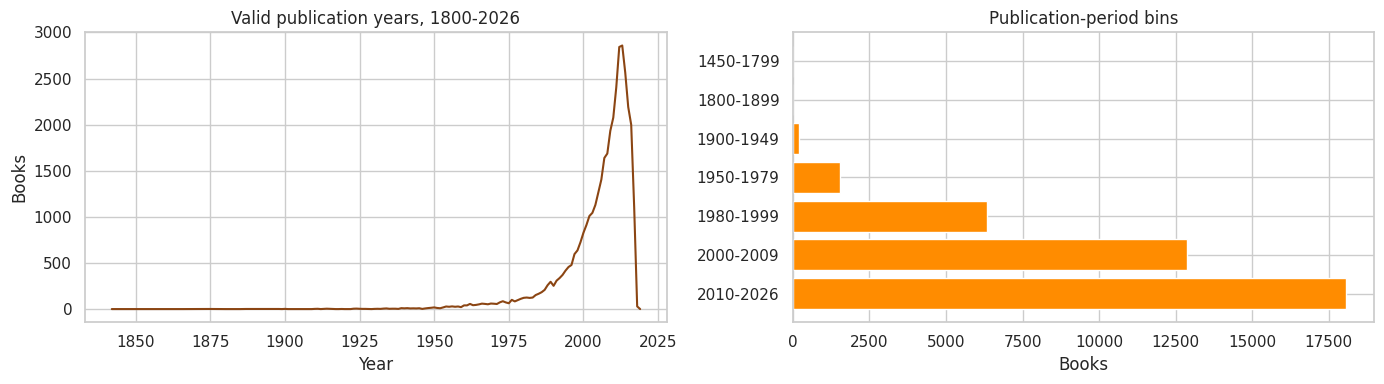

date_added   non-null parsed:  250,000 (100.0%)
date_updated non-null parsed:  250,000 (100.0%)
read_at      non-null parsed:   51,097 (20.4%)
started_at   non-null parsed:   39,660 (15.9%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
year_counts = valid_year.dropna().astype(int).value_counts().sort_index()
year_counts.loc[(year_counts.index >= 1800) & (year_counts.index <= 2026)].plot(ax=axes[0], color=BROWN)
axes[0].set_title('Valid publication years, 1800-2026')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Books')

axes[1].barh(year_bin_summary['publication_period'][::-1], year_bin_summary['books'][::-1], color=ORANGE)
axes[1].set_title('Publication-period bins')
axes[1].set_xlabel('Books')
plt.tight_layout()
plt.show()

for col in ['date_added', 'date_updated', 'read_at', 'started_at']:
    if col in interactions_temp.columns:
        parsed = pd.to_datetime(interactions_temp[col], errors='coerce', utc=True)
        print(f"{col:12s} non-null parsed: {parsed.notna().sum():>8,} ({parsed.notna().mean():.1%})")

**Decision for recommender:** Create a future `publication_year_clean` and broad `publication_period` bins from validated years only. Do not use raw extreme years as continuous model input, and keep date-based reading-duration features optional because complete start/read dates are sparse.

## 10. H7 — Format, Language, Publisher, and Edition Context

**Hypothesis:** Format, language, and publisher may represent edition quality, translation context, or availability, but their usefulness depends on missingness and cardinality.

**Evidence:** categorical distributions, missing-like rates, and eBook-vs-physical differences in satisfaction and popularity.

,column,value,count,pct
0,language_code,<missing>,25610,0.51220
1,language_code,eng,13399,0.26798
2,language_code,en-US,2407,0.04814
3,language_code,en-GB,1301,0.02602
4,language_code,ita,935,0.01870
...,...,...,...,...
58,publisher,Harper Perennial,174,0.00348
59,publisher,Penguin,172,0.00344
60,country_code,US,50000,1.00000
61,is_ebook,False,40384,0.80768


,column,dtype,nulls_raw,empty_strings_raw,non_null_raw,missing_like_total,missing_like_pct
1,asin,str,0,43227,50000,43227,0.86454
2,kindle_asin,str,0,25763,50000,25763,0.51526
3,language_code,str,0,25610,50000,25610,0.5122
6,isbn,str,0,13945,50000,13945,0.2789
8,format,str,0,11681,50000,11681,0.23362
9,publisher,str,0,11240,50000,11240,0.2248
10,isbn13,str,0,10964,50000,10964,0.21928
15,country_code,str,0,0,50000,0,0.0
17,is_ebook,str,0,0,50000,0,0.0


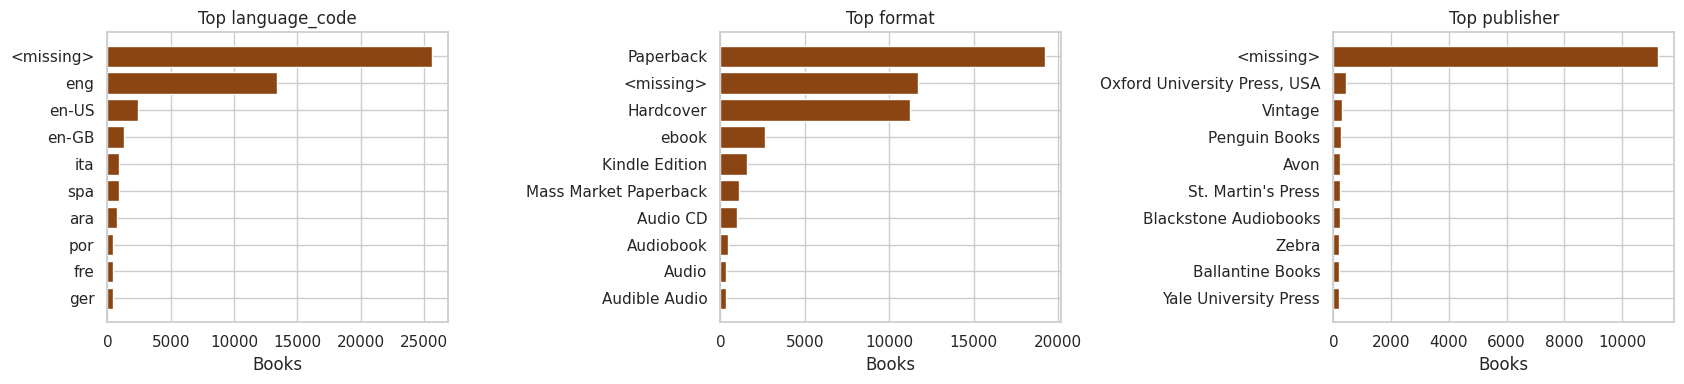

In [18]:
display(artifacts['categoricals'])

categorical_missing = books_missing_explicit[books_missing_explicit['column'].isin(['language_code', 'format', 'publisher', 'country_code', 'isbn', 'isbn13', 'asin', 'kindle_asin', 'is_ebook'])]
display(categorical_missing)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col, title in zip(axes, ['language_code', 'format', 'publisher'], ['Top language_code', 'Top format', 'Top publisher']):
    data = artifacts['categoricals'][artifacts['categoricals']['column'].eq(col)].head(10).copy()
    ax.barh(data['value'].astype(str)[::-1], data['count'][::-1], color=BROWN)
    ax.set_title(title)
    ax.set_xlabel('Books')
plt.tight_layout()
plt.show()

,is_ebook_bool,books,avg_rating_mean,avg_rating_median,ratings_count_median,ratings_count_p95
0,False,40384,3.876006,3.9,31.0,986.00
1,True,9616,3.881225,3.9,33.0,601.25


/tmp/ipykernel_3632930/1787810399.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Physical / non-eBook', 'eBook'])


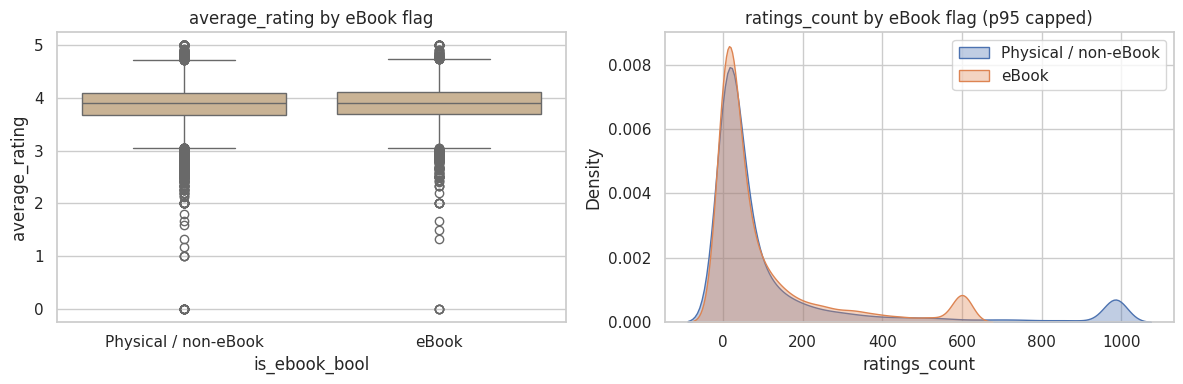

In [19]:
edition_eval = books_raw.copy()
for col in ['average_rating', 'ratings_count']:
    edition_eval[col] = pd.to_numeric(edition_eval[col], errors='coerce')
edition_eval['is_ebook_bool'] = edition_eval['is_ebook'].astype('string').str.lower().map({'true': True, 'false': False, '1': True, '0': False})

format_summary = edition_eval.groupby('is_ebook_bool', dropna=False).agg(
    books=('book_id', 'count'),
    avg_rating_mean=('average_rating', 'mean'),
    avg_rating_median=('average_rating', 'median'),
    ratings_count_median=('ratings_count', 'median'),
    ratings_count_p95=('ratings_count', lambda s: s.quantile(0.95)),
).reset_index()
display(format_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=edition_eval.dropna(subset=['average_rating', 'is_ebook_bool']), x='is_ebook_bool', y='average_rating', ax=axes[0], color='tan')
axes[0].set_title('average_rating by eBook flag')
axes[0].set_xticklabels(['Physical / non-eBook', 'eBook'])

for label, grp in edition_eval.dropna(subset=['is_ebook_bool']).groupby('is_ebook_bool'):
    rc = grp['ratings_count'].dropna()
    if len(rc) > 1:
        sns.kdeplot(rc.clip(upper=rc.quantile(0.95)), ax=axes[1], label='eBook' if label else 'Physical / non-eBook', fill=True, alpha=0.35)
axes[1].set_title('ratings_count by eBook flag (p95 capped)')
axes[1].set_xlabel('ratings_count')
axes[1].legend()
plt.tight_layout()
plt.show()

**Decision for recommender:** Use edition context cautiously. `country_code` should not be a primary feature when it has no variation in the sample; language, publisher, ISBN presence, and eBook flag may be retained for segmentation or metadata enrichment, but thematic shelves and author signals are more reliable for ranking.

## 11. Book-Level Engagement, Cold Start, and Rating Agreement

**Hypothesis:** History recommendation must handle sparse book-level interactions and distinguish Goodreads global ratings from ratings observed in the sampled interactions.

**Evidence:** interaction counts per book, cold-start thresholds, rating agreement between `average_rating` and sampled explicit ratings, and popularity concentration.

In [20]:
pop = eng_artifacts['popularity_distribution'].copy()
all_book_ids = books_raw[['book_id']].copy()
all_book_ids['book_id'] = all_book_ids['book_id'].astype(str)
pop['book_id'] = pop['book_id'].astype(str)
book_popularity = all_book_ids.merge(pop, on='book_id', how='left')
book_popularity['interaction_count'] = book_popularity['interaction_count'].fillna(0).astype(int)

cold_rows = []
for threshold in [0, 1, 5, 10, 25, 50]:
    count = int((book_popularity['interaction_count'] <= threshold).sum())
    cold_rows.append({'threshold': f'<= {threshold}', 'books': count, 'pct_books': count / len(book_popularity)})
cold_start_summary = pd.DataFrame(cold_rows)
display(cold_start_summary)

ra = eng_artifacts['rating_agreement'].dropna().copy()
ra['rating_delta'] = ra['mean_user_rating'] - ra['average_rating']
print(f'Books with both global and sampled ratings: {len(ra):,}')
display(ra['rating_delta'].describe().reset_index().rename(columns={'index': 'stat', 'rating_delta': 'value'}))

,threshold,books,pct_books
0,<= 0,38829,0.77658
1,<= 1,45112,0.90224
2,<= 5,48738,0.97476
3,<= 10,49446,0.98892
4,<= 25,49818,0.99636
5,<= 50,49938,0.99876


Books with both global and sampled ratings: 6,003


,stat,value
0,count,6003.00000
1,mean,-0.08458
2,std,0.81525
3,min,-3.37000
4,25%,-0.62000
5,50%,-0.01000
6,75%,0.44000
7,max,2.37000


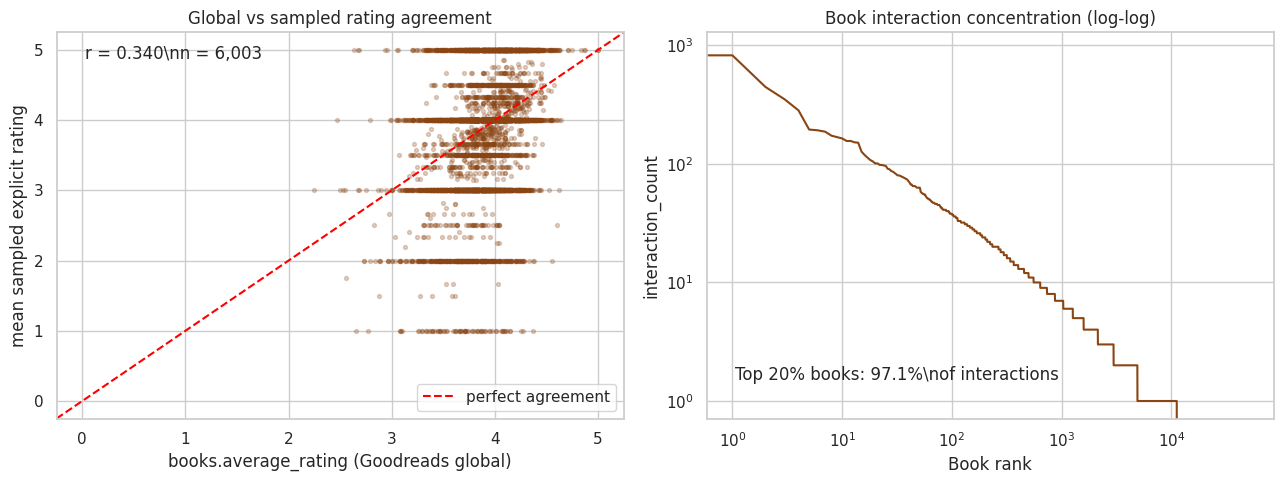

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if len(ra) > 1:
    axes[0].scatter(ra['average_rating'], ra['mean_user_rating'], alpha=0.25, s=8, color=BROWN)
    axes[0].axline((0, 0), slope=1, color='red', linestyle='--', label='perfect agreement')
    axes[0].set_xlabel('books.average_rating (Goodreads global)')
    axes[0].set_ylabel('mean sampled explicit rating')
    axes[0].set_title('Global vs sampled rating agreement')
    r = ra[['average_rating', 'mean_user_rating']].corr().iloc[0, 1]
    axes[0].text(0.05, 0.93, f'r = {r:.3f}\\nn = {len(ra):,}', transform=axes[0].transAxes)
    axes[0].legend()

ranked = book_popularity['interaction_count'].sort_values(ascending=False).reset_index(drop=True)
if len(ranked) > 0 and ranked.sum() > 0:
    ranked.plot(ax=axes[1], logy=True, logx=True, color=BROWN)
    axes[1].set_title('Book interaction concentration (log-log)')
    axes[1].set_xlabel('Book rank')
    axes[1].set_ylabel('interaction_count')
    top20 = ranked.iloc[:max(1, int(len(ranked) * 0.2))].sum() / ranked.sum()
    axes[1].text(0.05, 0.1, f'Top 20% books: {top20:.1%}\\nof interactions', transform=axes[1].transAxes)
plt.tight_layout()
plt.show()

**Decision for recommender:** Add a cold-start flag or route for low-interaction books, and use sampled user ratings as category-specific evidence rather than blindly trusting global Goodreads averages. Popularity should support confidence and exposure, not overwrite rating preference.

## 12. Numeric Profiles, Outliers, and Feature Risk

**Hypothesis:** Goodreads numeric metadata contains long tails and outliers that should be transformed or capped later, but the EDA should only diagnose them.

**Evidence:** descriptive statistics, IQR outlier counts, and correlations among numeric metadata.

,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,text_reviews_count,50000.0,31.802520,303.305668,0.0,1.00,1.00,2.0000,5.0,15.0,93.00,411.03,38878.0
1,average_rating,50000.0,3.877009,0.349292,0.0,2.92,3.29,3.6875,3.9,4.1,4.38,4.61,5.0
2,num_pages,36358.0,335.753507,198.971581,0.0,6.00,66.00,226.0000,318.0,408.0,648.00,973.00,6940.0
3,publication_day,31360.0,11.502136,10.094761,1.0,1.00,1.00,1.0000,9.0,20.0,29.00,31.00,31.0
4,publication_month,33613.0,6.378068,3.423079,1.0,1.00,1.00,3.0000,6.0,9.0,12.00,12.00,12.0
5,publication_year,39061.0,2006.120529,323.080776,13.0,1957.00,1981.00,2001.0000,2009.0,2013.0,2016.00,2017.00,65535.0
6,ratings_count,50000.0,377.878960,7781.389741,0.0,1.00,2.00,10.0000,31.0,106.0,886.00,4749.02,1207986.0


,column,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,rating,250000.0,1.60736,2.014959,0.0,0.0,0.0,0.0,0.0,4.0,5.0,5.0,5.0


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,text_reviews_count,2.0000,15.0,13.0000,93.00,411.03,34.50000,6215
1,average_rating,3.6875,4.1,0.4125,4.38,4.61,4.71875,251
2,num_pages,226.0000,408.0,182.0000,648.00,973.00,681.00000,1492
3,publication_day,1.0000,20.0,19.0000,29.00,31.00,48.50000,0
4,publication_month,3.0000,9.0,6.0000,12.00,12.00,18.00000,0
5,publication_year,2001.0000,2013.0,12.0000,2016.00,2017.00,2031.00000,6
6,ratings_count,10.0000,106.0,96.0000,886.00,4749.02,250.00000,6839


,column,q1,q3,iqr,p95,p99,upper_iqr_bound,outliers_iqr
0,rating,0.0,4.0,4.0,5.0,5.0,10.0,0


,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,to_read_count
average_rating,1.000000,0.013245,0.016118,0.175832,0.005527,0.088331
ratings_count,0.013245,1.000000,0.780849,0.016223,-0.000185,0.019569
text_reviews_count,0.016118,0.780849,1.000000,0.016842,0.000600,0.035131
num_pages,0.175832,0.016223,0.016842,1.000000,-0.001793,0.101365
publication_year,0.005527,-0.000185,0.000600,-0.001793,1.000000,0.000082
to_read_count,0.088331,0.019569,0.035131,0.101365,0.000082,1.000000


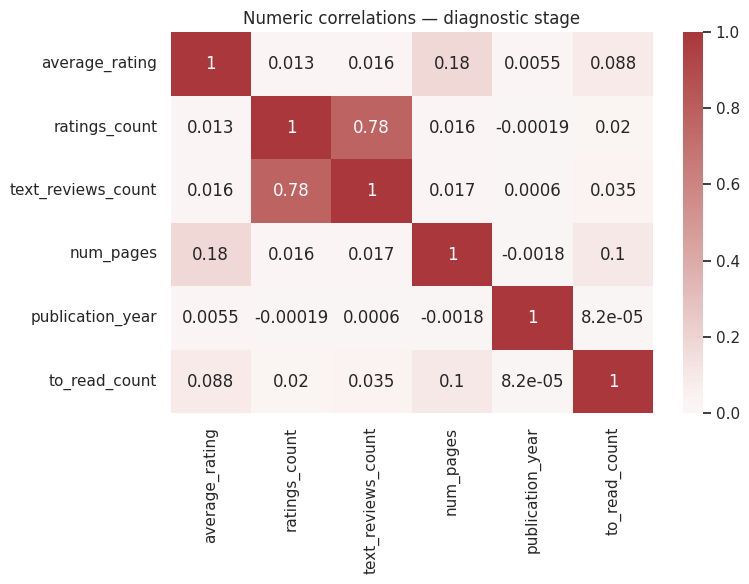

In [22]:
display(artifacts['books_numeric_profile'])
display(artifacts['interactions_numeric_profile'])
display(artifacts['books_outliers'])
display(artifacts['interactions_outliers'])

books_numeric = books_raw.copy()
for col in ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year']:
    if col in books_numeric.columns:
        books_numeric[col] = pd.to_numeric(books_numeric[col], errors='coerce')
books_numeric['to_read_count'] = theme_books['to_read_count']

num_cols = ['average_rating', 'ratings_count', 'text_reviews_count', 'num_pages', 'publication_year', 'to_read_count']
corr = books_numeric[[c for c in num_cols if c in books_numeric.columns]].corr(numeric_only=True)
display(corr)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='vlag', center=0, ax=ax)
ax.set_title('Numeric correlations — diagnostic stage')
plt.tight_layout()
plt.show()

**Decision for recommender:** Plan capped or log-transformed versions of long-tail count features during curation. Keep raw values for traceability, but do not feed extreme popularity counts directly into ranking without transformation.

## 13. Evidence Summary, Modeling Risks, and Candidate Features

This section consolidates the EDA into decisions for the later curation notebook. It does not execute curation or write processed outputs.

In [23]:
def scalar_from_table(df, key_col, key, value_col):
    hit = df.loc[df[key_col].eq(key), value_col]
    return hit.iloc[0] if len(hit) else np.nan

standalone_pct = float(scalar_from_table(series_artifacts['standalone_vs_series'], 'group', 'standalone', 'pct'))
shelf_only_pct = float(scalar_from_table(eng_artifacts['engagement_modes'], 'mode', 'shelf_only', 'pct'))
explicit_rating_pct = float(interactions_temp['rating_clean'].notna().mean())
zero_rating_pct = float((interactions_raw['rating'] == 0).mean())
duration_median = float(duration_artifacts['duration_distribution'].median()) if len(duration_artifacts['duration_distribution']) else np.nan
to_read_corr = float(quality_corr.loc[quality_corr['feature'].eq('to_read_count'), 'pearson_r'].iloc[0])

confirmed_evidence = pd.DataFrame([
    {'finding': 'Most books are standalones', 'evidence': f'{standalone_pct:.1%} standalone books'},
    {'finding': 'Collection behavior is dominant', 'evidence': f'{shelf_only_pct:.1%} shelf-only interactions'},
    {'finding': 'Rating 0 means missing explicit feedback', 'evidence': f'{zero_rating_pct:.1%} interactions have rating 0; {explicit_rating_pct:.1%} have ratings 1-5'},
    {'finding': 'Reading-duration data is sparse but informative', 'evidence': f"median={duration_median:.0f} days among complete 0-365 day records"},
    {'finding': 'Demand is weakly tied to satisfaction', 'evidence': f'to_read_count vs average_rating r={to_read_corr:.3f}'},
    {'finding': 'Publication year has invalid extremes', 'evidence': f"{int((pub_year < 1450).sum())} before 1450 and {int((pub_year > 2026).sum())} after 2026"},
])

display(confirmed_evidence)

,finding,evidence
0,Most books are standalones,75.8% standalone books
1,Collection behavior is dominant,55.4% shelf-only interactions
2,Rating 0 means missing explicit feedback,58.8% interactions have rating 0; 41.2% have r...
3,Reading-duration data is sparse but informative,median=6 days among complete 0-365 day records
4,Demand is weakly tied to satisfaction,to_read_count vs average_rating r=0.088
5,Publication year has invalid extremes,23 before 1450 and 6 after 2026


## 14. Conclusions — History & Biography

**Confirmed evidence**

1. History & Biography is mostly standalone in this sample: series metadata exists, but it is not the primary category structure.
2. The category has strong collection behavior: more than half of interactions are shelf-only, so saving a book should not be treated as equivalent to liking or finishing it.
3. `rating = 0` is the majority interaction state and should be modeled as missing explicit feedback, not dissatisfaction.
4. `to_read_count` has only a weak relationship with `average_rating`, supporting the separation of demand from quality.
5. History-specific shelves expose usable subthemes such as biography/memoir, military/war, politics, regional history, historical fiction, and science/ideas.
6. Publication years include impossible values, so raw temporal metadata requires validation before modeling.

**Risks for modeling**

- Author roles can contaminate authority signals if translators, editors, or contributors are treated as primary authors.
- Popularity counts have long tails and can overpower preference signals unless transformed.
- Sparse complete reading dates limit direct reading-speed personalization.
- Edition metadata is useful but unevenly populated, and some columns have little variation.

**Candidate features for later curation**

- Role-filtered author identifiers and author-count features.
- History shelf-theme indicators and theme co-occurrence features.
- Separate demand, visibility, satisfaction, and confidence signals.
- User rating-bias normalization for collaborative components.
- Clean publication periods and cold-start routing flags.

**Decision for recommender:** The History & Biography recommender should be hybrid by design: content retrieval from author authority and thematic shelves, collaborative scoring from explicit ratings adjusted by user bias, and confidence/exposure controls from interaction density and popularity features.